# Steerling-8B: Feature Attribution

Input feature attribution identifies which input tokens were responsible for each generated token. Our attribution is faithful because it is computed on the partial-mask snapshot the model actually saw when each token was unmasked, not the prompt alone or the finished text. It uses a MASK baseline (the trained absence-of-information state), so positions still masked in a snapshot get zero attribution by construction.

Interpretable model only.

**Requirements:** an interpretable Steerling checkpoint and a GPU with >= 18 GB VRAM.

## 1. Load the model

In [1]:
import torch
from transformers import AutoModel, AutoTokenizer
from steerling import SteerlingGenerator, GenerationConfig
from steerling.attribution.input_attribution import FaithfulOutputToInputAttributor

model_id = "guidelabs/steerling-8b"
model = AutoModel.from_pretrained(model_id, trust_remote_code=True, dtype=torch.bfloat16)
tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
generator = SteerlingGenerator.from_model(model, tokenizer, device="cuda")
assert generator.is_interpretable

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

## 2. Choose a prompt and attribute

The base model works in the text-continuation mode, so the input is a plain completion prompt

In [2]:
PROMPT = "The capital of Japan is"

config = GenerationConfig(max_new_tokens=64, steps=64, seed=0, cfg_scale=0.0)

attributor = FaithfulOutputToInputAttributor.from_generator(generator)
attr = attributor.attribute(PROMPT, config, n_steps=4)  # bump n_steps higher for better attribution

## 3. Validate the attribution

Attribution output can look reasonable while being wrong. Inspecting the results by eye does not tell you whether they are correct, so we validate with two quantitative checks.

**Completeness** is an axiom integrated gradients must satisfy (Sundararajan et al., 2017, arXiv:1703.01365), so checking it numerically verifies the implementation is correct. For each generated token, the attributions over input positions sum to the difference in that token's logit between the real input and the mask baseline:

$$\sum_{i} A_i \;=\; f(\text{input}) - f(\text{baseline})$$

where $A_i$ is the attribution of input position $i$ and $f$ is the target token's logit. The baseline holds the snapshot's `input_ids` fixed and swaps only the embeddings to mask, which is exactly the path IG integrates. Read the trend across `n_steps`, not any single value (see the note below the sweep).

**Deletion** is a standard faithfulness test from the interpretability literature (comprehensiveness, DeYoung et al., 2020, arXiv:1911.03429). Masking the top-attributed inputs should drop the target logit more than masking the same number of random inputs. Only positions the model saw when it committed a token (prompt or earlier commits) are eligible to mask.

In [3]:
import torch


def completeness_error(attr, attributor, verbose=True):
    """Check the integrated-gradients completeness axiom, averaged over targets.

    Completeness (Sundararajan et al., 2017) requires that a token's attributions
    sum to the gap in its logit between the real input and the baseline:

        sum_i A_i == f(input) - f(baseline)

    For each generated token this computes the gap with input_ids held at the
    snapshot and only the embeddings swapped to mask (the same path IG integrates),
    then compares it to the summed attributions. Returns the mean absolute error
    normalized by the mean gap, so 0 means perfect completeness and 1.0 (100%) means
    the error is as large as the gap itself.

    Args:
        attr: a FaithfulOutputToInputAttribution result.
        attributor: the attributor that produced it (for the backbone forward).
        verbose: if True, print per-run summary lines.

    Returns:
        Mean absolute completeness error divided by mean absolute gap (a fraction).
    """
    trace, backbone = attr.trace, attributor.backbone
    tok_emb = backbone.transformer.tok_emb
    mask_emb = tok_emb(torch.tensor([trace.mask_id], device=trace.device))[0]  # [D]

    def logit_from_emb(ids_row, emb, pos, tid):
        with torch.no_grad():
            h = backbone.transformer(input_ids=ids_row, input_embeds=emb, return_hidden=True)
            return float(backbone.transformer.lm_head(h)[0, pos, tid])

    abs_errs, gaps = [], []
    for n in range(attr.attributions.shape[0]):
        order = int(attr.target_orders[n])
        pos = int(attr.target_positions[n])
        tid = int(attr.target_token_ids[n])
        x = trace.reconstruct(order).unsqueeze(0)              # SAME input_ids for both terms
        emb_in = tok_emb(x)                                    # real embeddings
        emb_base = mask_emb.view(1, 1, -1).expand_as(emb_in)   # mask embeddings, snapshot input_ids
        gap = logit_from_emb(x, emb_in, pos, tid) - logit_from_emb(x, emb_base, pos, tid)
        s = float(attr.attributions[n].sum())                 # signed, raw
        abs_errs.append(abs(s - gap))
        gaps.append(abs(gap))

    mean_abs = sum(abs_errs) / len(abs_errs)
    mean_gap = sum(gaps) / len(gaps)
    if verbose:
        print(f"targets: {len(abs_errs)} generated tokens")
        print(f"gap is the difference in logit between the real input and the mask baseline")
        print(f"sum(attr) is the sum of the attributions of the generated token")
        print(f"normalized is the ratio of the absolute error to the gap. It should be close to 0 for faithful attribution")
        print(f"  mean |sum(attr) - gap| = {mean_abs:.4f}")
        print(f"  mean |gap|             = {mean_gap:.4f}")
        # normalized = 100% is the reference point where sum(attr) is no better than zero; values above it at low 
        # n_steps are expected (coarse right-Riemann overshoots) and are healthy as long as the error falls as n_steps grows.
        print(f"  normalized             = {100 * mean_abs / (mean_gap + 1e-8):.1f}%")
    return mean_abs / (mean_gap + 1e-8)

completeness_error(attr, attributor)


targets: 64 generated tokens
gap is the difference in logit between the real input and the mask baseline
sum(attr) is the sum of the attributions of the generated token
normalized is the ratio of the absolute error to the gap. It should be close to 0 for faithful attribution
  mean |sum(attr) - gap| = 14.8584
  mean |gap|             = 13.0526
  normalized             = 113.8%


1.1383422655044577

#### What the numbers mean

Integrated gradients (Sundararajan et al., 2017, arXiv:1703.01365) attributes a prediction to inputs by integrating gradients along a path from a baseline to the real input. `n_steps` is the number of points sampled along that path.

The **gap** is the quantity the attributions must reconstruct: the target token's logit at the real input minus its logit at the mask baseline, `f(input) - f(baseline)`. Completeness says the attributions for that token sum to the gap.

**Completeness error** for one token is `|sum(attr) - gap|`. We compute it for every generated token and average, so `mean |sum(attr) - gap|` is the average discrepancy in logit units.

**normalized** divides that by the average gap, `mean|sum(attr) - gap| / mean|gap|`, to express the error as a fraction of the gap being reconstructed. It is scale-independent and comparable across prompts.

**Why it can exceed 100%.** 100% is the point where `sum(attr)` is no better than predicting zero: if `sum(attr) = 0` the error is `|0 - gap| = |gap|`, exactly 100%. Below 100%, IG is meaningful. Above 100%, IG is worse than zero (it overshoots or points the wrong way). This happens at low `n_steps`, where the path is sampled too coarsely, and it comes down as `n_steps` grows. The sweep below shows the trend.

n_steps=   1:    97.4% mean completeness error
n_steps=   2:   186.7% mean completeness error
n_steps=   4:   113.8% mean completeness error
n_steps=   8:    87.9% mean completeness error
n_steps=  16:    65.4% mean completeness error
n_steps=  32:    46.6% mean completeness error
n_steps=  64:    41.1% mean completeness error


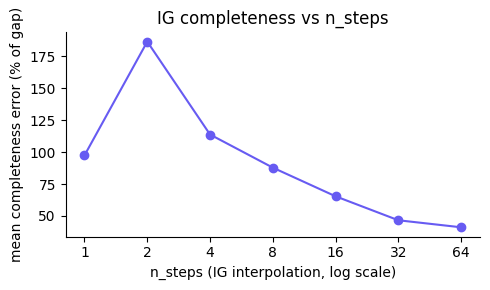

In [4]:
import matplotlib.pyplot as plt

trace = attr.trace  # reuse the recorded trace; no re-generation

# steps_list = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024] # complete but expensive sweep
steps_list = [1, 2, 4, 8, 16, 32, 64]

errs = []
for ns in steps_list:
    a = attributor.attribute_from_trace(trace, n_steps=ns)
    err = 100 * completeness_error(a, attributor, verbose=False)  # normalized fraction -> %
    errs.append(err)
    print(f"n_steps={ns:>4}:  {err:6.1f}% mean completeness error")

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(steps_list, errs, marker="o", color="#675BF2")
ax.set_xscale("log", base=2)
ax.set_xlabel("n_steps (IG interpolation, log scale)")
ax.set_ylabel("mean completeness error (% of gap)")
ax.set_title("IG completeness vs n_steps")
ax.set_xticks(steps_list)
ax.set_xticklabels(steps_list)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### Reading the completeness curve

Lower is better. The curve plots completeness error against `n_steps`; a lower error means the attributions reconstruct the logit gap more exactly.

`n_steps` is the number of points sampled along the integration path from baseline to input. More steps approximate the integral more accurately, so completeness error should fall as `n_steps` grows. This is a property of the method, independent of the model: it is the check that IG is being computed correctly.

Read the trend, not the rightmost value, for two reasons. First, right-Riemann integration (the sampling rule here) does not converge monotonically: it overshoots and undershoots as it refines, so a larger `n_steps` can occasionally show a slightly higher error than a smaller one. A single point can be a wiggle; the downward trend is the signal. Second, the number reported is an average over every generated token (the "aggregate"), and it converges slowly. Tokens whose logit barely moves between input and baseline (a small gap) produce large relative errors that inflate the average, so the aggregate lands higher than a single clean token would.

**Practical guidance.** Use `n_steps=64` for token selection and heatmaps. Raise it (128 or more) only when you need faithful attribution magnitudes.

In [5]:
import statistics

import torch

attr = a # get the attribution from the last sweep

def deletion_faithfulness(attr, attributor, k=3, trials=5, seed=0):
    """Mean target-logit drop from masking top-k attributed inputs vs k random inputs,
    averaged over all targets. Only positions visible when a token was committed are eligible.
    Ranks by |attribution| (importance is magnitude, not sign)."""
    trace, backbone = attr.trace, attributor.backbone
    g = torch.Generator().manual_seed(seed)

    def target_logit(ids, pos, tid):
        with torch.no_grad():
            emb = backbone.transformer.tok_emb(ids)
            hidden = backbone.transformer(input_ids=ids, input_embeds=emb, return_hidden=True)
            return float(backbone.transformer.lm_head(hidden)[0, pos, tid])

    top_drops, rand_drops = [], []
    for n in range(attr.attributions.shape[0]):
        order = int(attr.target_orders[n])
        pos = int(attr.target_positions[n])
        tid = int(attr.target_token_ids[n])
        x0 = trace.reconstruct(order).unsqueeze(0)
        revealed = [
            p for p in attr._scope_positions("all").tolist()
            if p != pos and int(trace._order_at[p]) < order
        ]
        if len(revealed) < k:
            continue
        base = target_logit(x0, pos, tid)
        vec = attr.attributions[n].abs()
        top = sorted(revealed, key=lambda p: float(vec[p]), reverse=True)[:k]
        xt = x0.clone()
        xt[0, top] = trace.mask_id
        top_drops.append(base - target_logit(xt, pos, tid))
        trial = []
        for _ in range(trials):
            rp = [revealed[i] for i in torch.randperm(len(revealed), generator=g)[:k].tolist()]
            xr = x0.clone()
            xr[0, rp] = trace.mask_id
            trial.append(base - target_logit(xr, pos, tid))
        rand_drops.append(statistics.mean(trial))

    print(f"targets used: {len(top_drops)}")
    print(f"  mean drop, top-{k} attributed = {statistics.mean(top_drops):+.3f}")
    print(f"  mean drop, {k} random         = {statistics.mean(rand_drops):+.3f}")

deletion_faithfulness(attr, attributor, k=3)

targets used: 64
  mean drop, top-3 attributed = +3.090
  mean drop, 3 random         = +0.709


## 4. Per-token attribution

In [6]:
import html as _html
import torch
from IPython.display import HTML


def render_per_token(attr, generator, k=5, scope="all", max_tokens=40):
    """Inline HTML view: each generated token with its top-k contributing input
    tokens, colored by signed attribution (blue +, red -) and normalized per row.
    ● marks a prompt source, ○ a generated source."""
    tok = generator.tokenizer
    special = attr._special_id_set(tok)
    tokens = attr.trace.committed_tokens()
    types = attr.trace.position_types()
    scope_pos = attr._scope_positions(scope).tolist()

    blue = {1: "#E6F1FB", 2: "#B5D4F4", 3: "#85B7EB", "t": "#0C447C"}
    red = {1: "#FCEBEB", 2: "#F7C1C1", 3: "#F09595", "t": "#791F1F"}

    def keep(p):
        tid = int(tokens[p])
        return tid not in special and tok.decode([tid]).strip() != ""

    order = torch.argsort(attr.target_positions).tolist()
    rows = []
    for n in order[:max_tokens]:
        tgt_pos = int(attr.target_positions[n])
        tgt_id = int(attr.target_token_ids[n])
        # skip special tokens
        if tgt_id in special:
            continue
        vec = attr.explanation(tgt_pos)
        cand = sorted(
            ((p, float(vec[p])) for p in scope_pos if keep(p)),
            key=lambda x: abs(x[1]),
            reverse=True,
        )[:k]
        if not cand:
            continue
        row_max = max((abs(s) for _, s in cand), default=1e-8) or 1e-8
        chips = []
        for p, score in cand:
            rel = abs(score) / row_max
            ramp = blue if score >= 0 else red
            bg = ramp[3] if rel >= 0.66 else ramp[2] if rel >= 0.33 else ramp[1]
            marker = "\u25cf" if types[p].value == "prompt" else "\u25cb"
            label = _html.escape(tok.decode([int(tokens[p])]))
            chips.append(
                f'<span style="display:inline-flex;align-items:center;gap:4px;background:{bg};'
                f'color:{ramp["t"]};border-radius:6px;padding:2px 8px;font-size:13px;white-space:nowrap;">'
                f'<span style="font-size:8px;opacity:.8;">{marker}</span>'
                f'<span style="font-family:monospace;font-weight:600;">{label}</span>'
                f'<span style="font-size:11px;opacity:.7;">{"+" if score >= 0 else ""}{score:.1f}</span></span>'
            )
        tgt_label = _html.escape(tok.decode([tgt_id]))
        rows.append(
            '<div style="display:flex;align-items:flex-start;gap:12px;padding:6px 0;'
            'border-top:0.5px solid #ddd;">'
            f'<div style="flex:0 0 140px;"><span style="color:#999;font-family:monospace;'
            f'font-size:11px;">{tgt_pos}</span> <span style="font-family:monospace;font-weight:600;'
            f'font-size:14px;">{tgt_label}</span></div>'
            f'<div style="flex:1;display:flex;flex-wrap:wrap;gap:6px;">{"".join(chips)}</div></div>'
        )

    legend = (
        '<div style="display:flex;flex-wrap:wrap;gap:16px;font-size:13px;color:#666;'
        'margin-bottom:12px;"><span>\u25cf prompt source</span><span>\u25cb generated source</span>'
        '<span style="color:#0C447C;">blue&nbsp;+ pushes up</span>'
        '<span style="color:#791F1F;">red&nbsp;\u2212 pushes down</span></div>'
    )
    return HTML(legend + "".join(rows))


render_per_token(attr, generator, k=5, scope="all")